# Event decay v2: conditioning on realized execution sweep

This workbench replaces fill-count/price-level classes with the economically direct measure of event aggression: the side-aligned difference between the first and last execution prices.

Fill count and price-level count remain visible as secondary diagnostics, but they do not define the primary curves.

## Definitions

For reconstructed event $$i$$ with aggressor side $$\epsilon_i$$:

$$
S_i=10^4\epsilon_i\log\left(\frac{P_i^{last}}{P_i^{first}}\right)
$$

is the realized endpoint sweep. Immediate impact is decomposed as:

$$
I_i^{immediate}
=10^4\epsilon_i\log\left(\frac{P_i^{first}}{P_{i-1}^{last}}\right)
+S_i.
$$

Subsequent total and post-event responses are:

$$
R_i(h)=10^4\epsilon_i\log\left(\frac{P_{i,h}}{P_{i-1}^{last}}\right),
\qquad
R_i^{post}(h)=10^4\epsilon_i\log\left(\frac{P_{i,h}}{P_i^{last}}\right).
$$

Positive sweeps are divided by quartile boundaries calibrated through December 2022 and then frozen. A negative side-aligned endpoint movement is retained as an anomaly rather than treated as aggressive execution.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
RESULT_ROOT = REPO / 'alpha-search' / 'reports' / 'event_decay_sweep_v2'
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})

## Manual controls

In [2]:
PERIOD = 'validation'       # development, validation, later_exposed
SIDE_VIEW = 'equal_side'    # equal_side, buy, sell
SHOW_CONFIDENCE_BANDS = True
PRIMARY_CLASSES = ['no_endpoint_sweep', 'sweep_q1', 'sweep_q2', 'sweep_q3', 'sweep_q4']

assert PERIOD in {'development', 'validation', 'later_exposed'}
assert SIDE_VIEW in {'equal_side', 'buy', 'sell'}

## Load compact daily summaries

In [3]:
required = ['run_manifest.json', 'sweep_quantile_cuts.csv',
            'event_sweep_class_counts.csv', 'decay_sample_summary.csv', 'decay_daily.csv']
missing = [name for name in required if not (RESULT_ROOT / name).exists()]
if missing:
    raise FileNotFoundError(
        f'Missing {missing}. Run alpha-search/scripts/run_event_decay_by_execution.py first.'
    )

manifest = json.loads((RESULT_ROOT / 'run_manifest.json').read_text())
cuts = pl.read_csv(RESULT_ROOT / 'sweep_quantile_cuts.csv')
counts = pl.read_csv(RESULT_ROOT / 'event_sweep_class_counts.csv')
sample = pl.read_csv(RESULT_ROOT / 'decay_sample_summary.csv')
daily = pl.read_csv(RESULT_ROOT / 'decay_daily.csv').with_columns(
    pl.when(pl.col('source_month') <= '2022-12').then(pl.lit('development'))
    .when(pl.col('source_month') <= '2024-12').then(pl.lit('validation'))
    .otherwise(pl.lit('later_exposed')).alias('period')
)
display(manifest)
display(cuts)
print(f"Sampled {sample['sample_events'].sum():,} anchors from {sample['source_events'].sum():,} events")

{'version': 'event_decay_sweep_v2',
 'symbol': 'BTCUSDT',
 'event_rule': 'timestamp_direction_v1',
 'first_month': '2019-09',
 'last_month': '2026-05',
 'calibration_end_month': '2022-12',
 'calibration_positive_sweep_events': 399803,
 'sample_modulus': 500,
 'horizons_ms': [100,
  250,
  500,
  1000,
  2000,
  5000,
  10000,
  15000,
  30000,
  60000,
  120000,
  300000,
  600000,
  900000,
  1800000],
 'sweep_quantiles': [0.25, 0.5, 0.75],
 'sweep_cuts_bps': [0.09517935095902053,
  0.29960617558970826,
  0.6857707744908033],
 'primary_classification': 'side_aligned_first_to_last_execution_price_displacement',
 'secondary_diagnostics': ['quantity',
  'fill_count',
  'price_level_count',
  'min_max_execution_span'],
 'holdout_note': 'Jun-Aug 2026 excluded by default and not inspected.'}

boundary,training_quantile,endpoint_sweep_bps
str,f64,f64
"""q25_q50""",0.25,0.095179
"""q50_q75""",0.5,0.299606
"""q75_q100""",0.75,0.685771


Sampled 4,843,727 anchors from 2,422,612,186 events


## Exact sweep-class frequencies and economic size

category,events,total_quantity,event_share,quantity_share,mean_endpoint_sweep_bps,mean_quantity
str,i64,f64,f64,f64,f64,f64
"""opposite_endpoint_move""",576709,487569.723,0.000238,0.000631,-0.879366,0.845435
"""no_endpoint_sweep""",2050492584,3.3510e8,0.846397,0.433539,0.0,0.163424
"""sweep_q1""",128242475,5.5318e7,0.052936,0.071568,0.041512,0.431355
"""sweep_q2""",109675078,6.8776e7,0.045271,0.08898,0.17893,0.627089
"""sweep_q3""",72251794,8.1829e7,0.029824,0.105867,0.458071,1.132553
"""sweep_q4""",61373546,2.3143e8,0.025334,0.299415,1.599442,3.770845


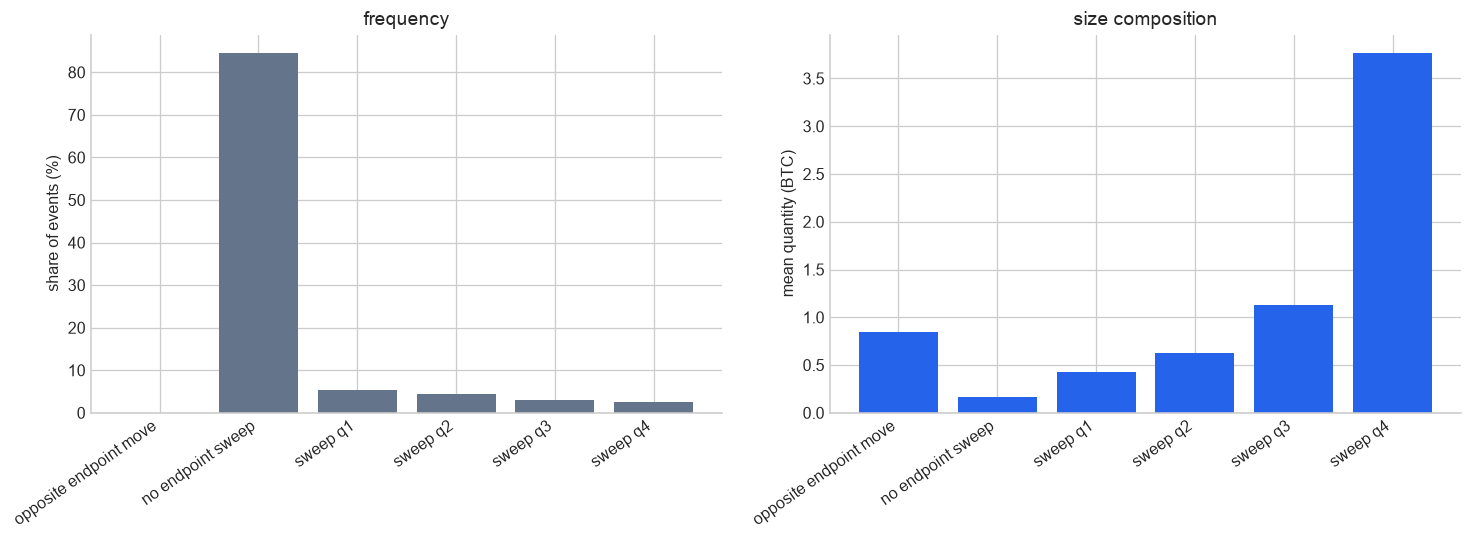

In [4]:
count_summary = counts.group_by('category').agg(
    pl.col('events').sum(),
    pl.col('total_quantity').sum(),
    (pl.col('mean_endpoint_sweep_bps') * pl.col('events')).sum().alias('_weighted_sweep'),
    (pl.col('mean_quantity') * pl.col('events')).sum().alias('_weighted_quantity'),
).with_columns(
    (pl.col('events') / pl.col('events').sum()).alias('event_share'),
    (pl.col('total_quantity') / pl.col('total_quantity').sum()).alias('quantity_share'),
    (pl.col('_weighted_sweep') / pl.col('events')).alias('mean_endpoint_sweep_bps'),
    (pl.col('_weighted_quantity') / pl.col('events')).alias('mean_quantity'),
).drop('_weighted_sweep', '_weighted_quantity').sort('mean_endpoint_sweep_bps')
display(count_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
labels = [value.replace('_', ' ') for value in count_summary['category']]
x = np.arange(len(labels))
axes[0].bar(x, 100 * count_summary['event_share'], color='#64748b')
axes[1].bar(x, count_summary['mean_quantity'], color='#2563eb')
for ax in axes:
    ax.set_xticks(x, labels, rotation=35, ha='right')
axes[0].set_ylabel('share of events (%)')
axes[1].set_ylabel('mean quantity (BTC)')
axes[0].set_title('frequency')
axes[1].set_title('size composition')
plt.tight_layout()
plt.show()

The quantity plot is essential: a difference between sweep classes is not automatically a sweep effect if the large-sweep events are also much larger. Matching or regression controls for quantity and volatility are the next causal-identification layer.

## Construct raw and equal-side daily paths

In [5]:
buy = daily.filter(pl.col('side') == 'buy').select(
    'period', 'category', 'utc_day', 'horizon_ms', 'horizon_seconds',
    pl.col('mean_immediate_response_bps').alias('buy_immediate'),
    pl.col('mean_total_response_bps').alias('buy_total'),
    pl.col('mean_post_event_response_bps').alias('buy_post'),
)
sell = daily.filter(pl.col('side') == 'sell').select(
    'period', 'category', 'utc_day', 'horizon_ms',
    pl.col('mean_immediate_response_bps').alias('sell_immediate'),
    pl.col('mean_total_response_bps').alias('sell_total'),
    pl.col('mean_post_event_response_bps').alias('sell_post'),
)
paired = buy.join(sell, on=['period', 'category', 'utc_day', 'horizon_ms'], how='inner').with_columns(
    ((pl.col('buy_immediate') + pl.col('sell_immediate')) / 2).alias('immediate'),
    ((pl.col('buy_total') + pl.col('sell_total')) / 2).alias('total'),
    ((pl.col('buy_post') + pl.col('sell_post')) / 2).alias('post'),
)

if SIDE_VIEW == 'equal_side':
    path_daily = paired.select('period', 'category', 'utc_day', 'horizon_ms',
                               'horizon_seconds', 'immediate', 'total', 'post')
else:
    path_daily = daily.filter(pl.col('side') == SIDE_VIEW).select(
        'period', 'category', 'utc_day', 'horizon_ms', 'horizon_seconds',
        pl.col('mean_immediate_response_bps').alias('immediate'),
        pl.col('mean_total_response_bps').alias('total'),
        pl.col('mean_post_event_response_bps').alias('post'),
    )

curve = path_daily.group_by('period', 'category', 'horizon_ms', 'horizon_seconds').agg(
    pl.len().alias('days'),
    pl.col('immediate').mean(),
    pl.col('total').mean(),
    pl.col('post').mean(),
    (pl.col('total').std() / pl.len().sqrt()).alias('total_se'),
    (pl.col('post').std() / pl.len().sqrt()).alias('post_se'),
).sort('category', 'horizon_ms')

## Total response by realized sweep

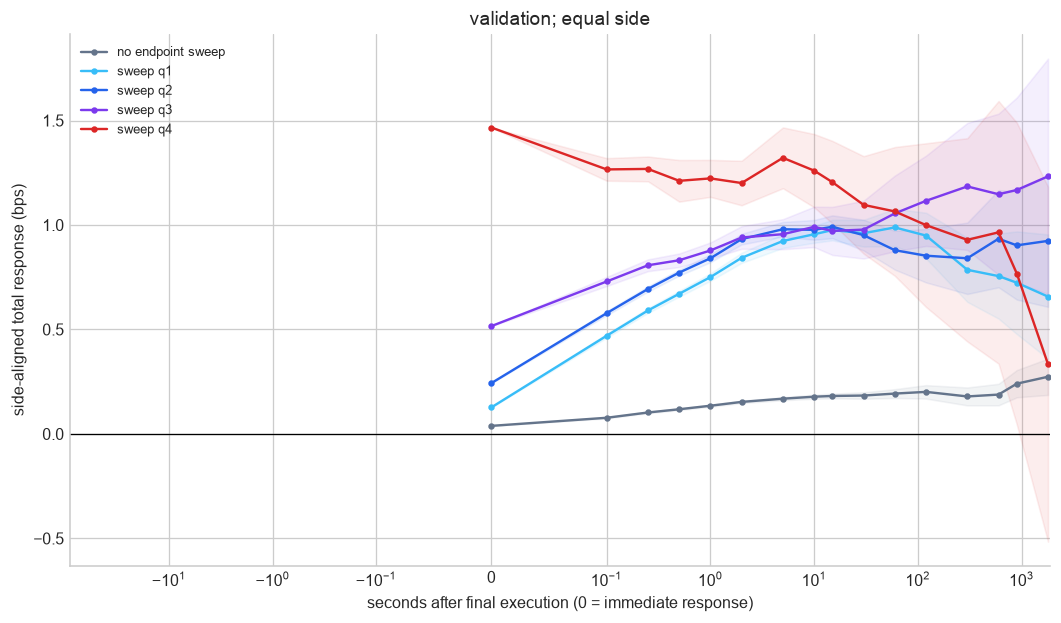

In [6]:
colours = {'no_endpoint_sweep': '#64748b', 'sweep_q1': '#38bdf8',
           'sweep_q2': '#2563eb', 'sweep_q3': '#7c3aed', 'sweep_q4': '#dc2626'}
fig, ax = plt.subplots(figsize=(11, 6))
for category in PRIMARY_CLASSES:
    part = curve.filter((pl.col('period') == PERIOD) & (pl.col('category') == category)).sort('horizon_ms')
    if part.is_empty():
        continue
    x = np.r_[0.0, part['horizon_seconds'].to_numpy()]
    y = np.r_[part['immediate'][0], part['total'].to_numpy()]
    ax.plot(x, y, marker='o', ms=3, color=colours[category], label=category.replace('_', ' '))
    if SHOW_CONFIDENCE_BANDS:
        se = np.r_[0.0, part['total_se'].to_numpy()]
        ax.fill_between(x, y - 1.96 * se, y + 1.96 * se, color=colours[category], alpha=.08)
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('symlog', linthresh=.1)
ax.set_xlabel('seconds after final execution (0 = immediate response)')
ax.set_ylabel('side-aligned total response (bps)')
ax.set_title(f'{PERIOD}; {SIDE_VIEW.replace("_", " ")}')
ax.legend(fontsize=8)
plt.show()

## Post-event continuation or reversal

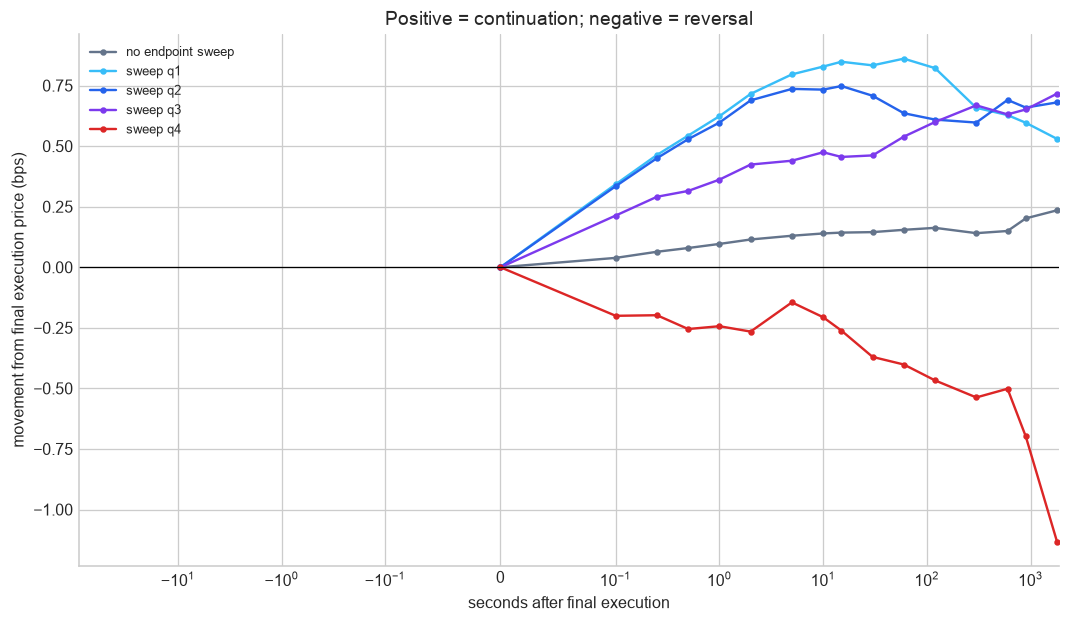

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
for category in PRIMARY_CLASSES:
    part = curve.filter((pl.col('period') == PERIOD) & (pl.col('category') == category)).sort('horizon_ms')
    if part.is_empty():
        continue
    x = np.r_[0.0, part['horizon_seconds'].to_numpy()]
    y = np.r_[0.0, part['post'].to_numpy()]
    ax.plot(x, y, marker='o', ms=3, color=colours[category], label=category.replace('_', ' '))
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('symlog', linthresh=.1)
ax.set_xlabel('seconds after final execution')
ax.set_ylabel('movement from final execution price (bps)')
ax.set_title('Positive = continuation; negative = reversal')
ax.legend(fontsize=8)
plt.show()

## Incremental reaction and counterreaction

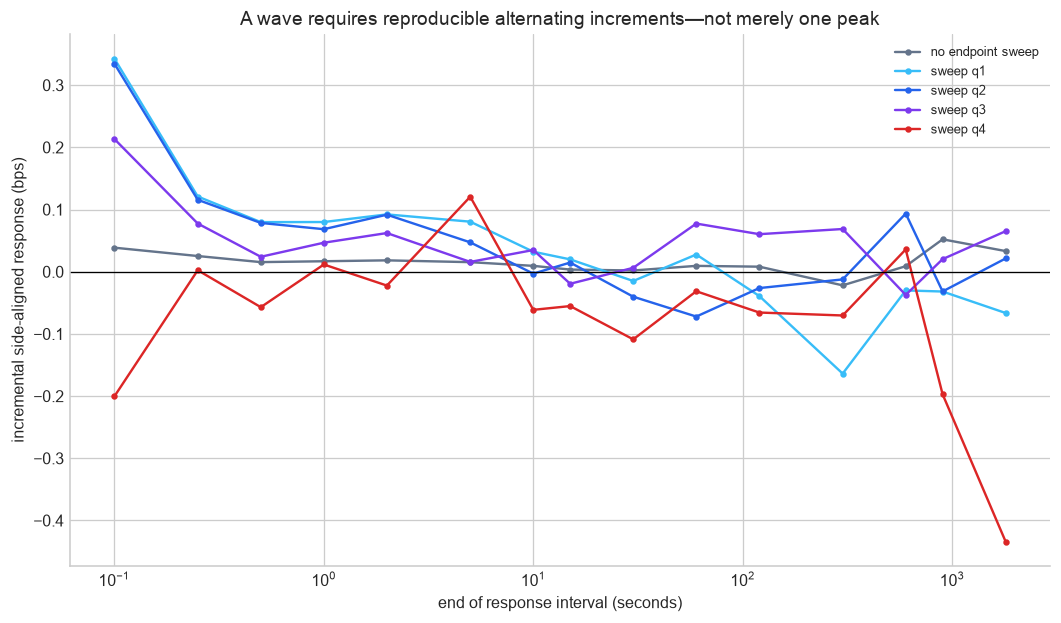

In [8]:
base = path_daily.select(
    'period', 'category', 'utc_day',
    pl.lit(0, dtype=pl.Int64).alias('horizon_ms'),
    pl.lit(0.0).alias('horizon_seconds'),
    pl.col('immediate').alias('total'),
)
increments = pl.concat([
    base,
    path_daily.select('period', 'category', 'utc_day', 'horizon_ms', 'horizon_seconds', 'total')
]).sort('period', 'category', 'utc_day', 'horizon_ms').with_columns(
    pl.col('total').diff().over('period', 'category', 'utc_day').alias('increment')
).filter(pl.col('horizon_ms') > 0).group_by(
    'period', 'category', 'horizon_ms', 'horizon_seconds'
).agg(
    pl.col('increment').mean().alias('mean_increment'),
    (pl.col('increment').std() / pl.len().sqrt()).alias('standard_error'),
    pl.len().alias('days'),
).sort('category', 'horizon_ms')

fig, ax = plt.subplots(figsize=(11, 6))
for category in PRIMARY_CLASSES:
    part = increments.filter((pl.col('period') == PERIOD) & (pl.col('category') == category))
    ax.plot(part['horizon_seconds'], part['mean_increment'], marker='o', ms=3,
            color=colours[category], label=category.replace('_', ' '))
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('log')
ax.set_xlabel('end of response interval (seconds)')
ax.set_ylabel('incremental side-aligned response (bps)')
ax.set_title('A wave requires reproducible alternating increments—not merely one peak')
ax.legend(fontsize=8)
plt.show()

## Reconstruction/path anomalies

In [9]:
diagnostic_categories = ['opposite_endpoint_move', 'path_excursion_returned_to_start']
display(sample.select(
    'source_month', 'sample_events', 'positive_sweep_events',
    'no_endpoint_sweep_events', 'opposite_endpoint_move_events',
    'path_excursion_returned_to_start_events'
).tail(24))

diagnostic = daily.filter(
    (pl.col('side') == 'all') & pl.col('category').is_in(diagnostic_categories)
).group_by('source_month', 'category').agg(
    pl.col('sample_events').first(),
    pl.col('mean_endpoint_sweep_bps').first(),
    pl.col('mean_execution_span_bps').first(),
).sort('source_month', 'category')
display(diagnostic.tail(30))

source_month,sample_events,positive_sweep_events,no_endpoint_sweep_events,opposite_endpoint_move_events,path_excursion_returned_to_start_events
str,i64,i64,i64,i64,i64
"""2024-06""",42801,5171,37623,7,3
"""2024-07""",59149,7530,51601,18,6
"""2024-08""",72120,10512,61575,33,17
"""2024-09""",55438,7118,48307,13,21
"""2024-10""",55871,7764,48100,7,15
…,…,…,…,…,…
"""2026-01""",46334,8066,38252,16,7
"""2026-02""",72634,17692,54907,35,14
"""2026-03""",63689,12573,51095,21,16


source_month,category,sample_events,mean_endpoint_sweep_bps,mean_execution_span_bps
str,str,i64,f64,f64
"""2025-03""","""opposite_endpoint_move""",3,-0.036019,0.036019
"""2025-03""","""path_excursion_returned_to_sta…",5,0.0,0.070602
"""2025-04""","""opposite_endpoint_move""",1,-0.399832,0.635019
"""2025-04""","""path_excursion_returned_to_sta…",1,0.0,0.012081
"""2025-05""","""opposite_endpoint_move""",1,-0.031114,0.031114
…,…,…,…,…
"""2026-03""","""path_excursion_returned_to_sta…",2,0.0,0.130629
"""2026-04""","""opposite_endpoint_move""",1,-0.205348,0.205348
"""2026-04""","""path_excursion_returned_to_sta…",1,0.0,0.254259


## Interpretation limits and next model

- Endpoint sweep measures realized execution aggression more directly than fill multiplicity.
- Volume still confounds comparisons: large events are more likely to sweep. The next estimation stage should match sweep classes on quantity, volatility, side and activity, or include them in a local-projection regression.
- Raw response includes the effect of correlated subsequent order flow. It is not yet the isolated decay kernel of one hypothetical trade.
- A propagator/local-projection model controlling for lagged and subsequent signed flow is required before interpreting repeated sign changes as a reaction wave.
- Fill count and price-level count should only be promoted if they add predictive information conditional on quantity and realized sweep.